# TDS forward and inverse: FESTIM vs. Chebyshev pseudospectral

This notebook reproduces the FESTIM workshop tungsten thermal-desorption (TDS)
example with two methods, then uses both methods inside a Levenberg–Marquardt
loop to recover the trap parameters from a noisy desorption flux.

The physics is one-dimensional hydrogen transport in a 20 µm tungsten foil
with two McNabb–Foster trapping reactions. The dynamics has three phases:

1. **Implantation** ($0 \le t \le 400\,\mathrm{s}$): a Gaussian-profile ion
   source loads the foil with H. Temperature is held at 300 K.
2. **Resting** ($400 \le t \le 450\,\mathrm{s}$): source off, T still 300 K.
3. **TDS ramp** ($450 \le t \le 500\,\mathrm{s}$): T ramps at 8 K/s up to
   700 K, releasing trapped H. The desorption flux at the surfaces is the
   thermal-desorption spectrum.

The governing equations on $x \in [0, L]$ are

$$
\partial_t c_m = D(T)\,\partial_x^2 c_m + S(x,t)
              - \sum_{i=1,2}\!\bigl[\nu_{m,i}\,c_m(n_i - c_{t,i}) - \nu_{r,i}\,c_{t,i}\bigr]
$$
$$
\partial_t c_{t,i} = \nu_{m,i}\,c_m(n_i - c_{t,i}) - \nu_{r,i}\,c_{t,i},
\quad i = 1, 2,
$$

with $c_m(0,t) = c_m(L,t) = 0$, all initial concentrations zero, and Arrhenius
rate constants $D = D_0 e^{-E_D/k_BT}$, $\nu_m = k_0 e^{-E_k/k_BT}$, and
$\nu_r = p_0 e^{-E_p/k_BT}$. The unknowns of the inverse problem are the
trap site fractions $n_1, n_2$ and the detrapping energies $E_{p,1}, E_{p,2}$.

The point of the comparison is that the spatial structure of the problem
is sharp (a 2.5 nm Gaussian source in a 20 µm domain — a width-to-domain
ratio of $1.25 \times 10^{-4}$). FESTIM resolves this with a graded
finite-element mesh of about 700 vertices. The Chebyshev pseudospectral
solver in `chebyshev_festim.py` instead uses a sinh-stretched
Chebyshev–Lobatto grid that naturally clusters nodes near the boundary
where the source lives, achieving spectral convergence with $N+1 \approx 65$
to $97$ nodes. The differentiation matrices are precomputed once and reused
across every time step and every parameter evaluation in the inverse loop.


## 1. Imports and constants

`chebyshev_festim` is the in-repo Chebyshev pseudospectral solver. It
mirrors FESTIM's public API (`HydrogenTransportProblem`, `Material`,
`Species`, `Reaction`, `SurfaceFlux`, ...) so user code reads almost
identically to a FESTIM run.


In [1]:
import os
import time
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import chebyshev_festim as CF


### 1.1 Physical constants and the workshop tutorial parameters

These match the FESTIM workshop "TDS for tungsten" tutorial verbatim.
Quantities are in SI units, with concentrations in mol/m³ throughout
(divide by Avogadro to convert atoms → mol).

`THETA_TRUE` is the parameter vector the inverse problem will try to
recover from the noisy desorption flux: $(n_1, n_2, E_{p,1}, E_{p,2})$.


In [2]:
# physical constants
AVOGADRO = 6.02214076e23          # 1/mol
W_DENSITY = 6.3e28                # tungsten atoms / m^3
K_B_EV = 8.617333262145e-5        # eV / K

# tutorial geometry and TDS protocol
L = 20e-6                         # foil thickness (m)
IMPLANT_TIME = 400.0              # s, implantation duration
INCIDENT_FLUX = 2.5e19 / AVOGADRO # mol/m^2/s, ion flux during implantation
CENTER, WIDTH = 4.5e-9, 2.5e-9    # m, Gaussian source: mean and std-dev
T_IMPLANT = 300.0                 # K, holding temperature pre-TDS
T_RAMP = 8.0                      # K/s, TDS ramp rate
START_TDS = IMPLANT_TIME + 50.0   # s, ramp begins at t=450
FINAL_TIME = 500.0                # s, end of simulation

# true trap parameters (the targets of the inverse problem)
N1_TRUE, N2_TRUE = 1.3e-3, 4e-4   # site fractions (dimensionless)
E1_TRUE, E2_TRUE = 0.87, 1.0      # detrapping activation energies (eV)
THETA_TRUE = np.array([N1_TRUE, N2_TRUE, E1_TRUE, E2_TRUE])

# trapping prefactor: 4.1e-7 / (1.1e-10^2 * 6 * w_atom_density_in_mol_per_m3).
# this is the standard McNabb-Foster expression for nu_m as used by FESTIM.
K0_TRAP = 4.1e-7 / (1.1e-10**2 * 6 * (W_DENSITY / AVOGADRO))

# all figures from this notebook land here
FIG_DIR = os.path.join("..", "figs")
os.makedirs(FIG_DIR, exist_ok=True)
print("figures will be written to", os.path.abspath(FIG_DIR))


figures will be written to /Users/colinweaver/Documents/MIT Documents/18.336/18336Project/figs


## 2. The FESTIM forward model

This builds the FESTIM `HydrogenTransportProblem` exactly as in the workshop
tutorial: a graded mesh that crowds 200 vertices into the first 30 nm to
resolve the source, a `ParticleSource` whose temporal gate is the sharp
indicator $t \le t_\mathrm{imp}$, a piecewise temperature schedule, and an
adaptive backward-Euler stepper with milestones at the implantation cutoff
and the start of the ramp.

The function returns the time series $t$ and the *total* desorption flux
$\Phi_\mathrm{left} + \Phi_\mathrm{right}$. FESTIM's `SurfaceFlux` returns
the outward flux $-D\,\partial_x c_m \cdot \hat{n}$, so summing the two
surfaces gives the rate at which H leaves the foil — the experimentally
measured TDS signal.


In [3]:
def run_festim_tds(n1, n2, E1, E2):
    '''FESTIM forward solve at the four trap parameters.

    Returns (t, flux_total) where flux_total = flux_left + flux_right.
    Mirrors the workshop tutorial structure, line for line.
    '''
    import festim as F
    import ufl

    my = F.HydrogenTransportProblem()

    # graded mesh: 200 vertices in [0, 30 nm], 300 in [30 nm, 3 um], 200 in [3 um, L].
    # the first block resolves the 2.5 nm Gaussian source.
    vertices = np.concatenate([
        np.linspace(0, 30e-9, num=200),
        np.linspace(30e-9, 3e-6, num=300),
        np.linspace(3e-6, L, num=200),
    ])
    my.mesh = F.Mesh1D(vertices)

    # tungsten diffusivity D = D_0 * exp(-E_D/kT)
    tungsten = F.Material(D_0=4.1e-7, E_D=0.39)
    vol = F.VolumeSubdomain1D(id=1, borders=[0, L], material=tungsten)
    left = F.SurfaceSubdomain1D(id=2, x=0)
    right = F.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    # one mobile species (H) and two trapped species (immobile).
    # ImplicitSpecies n_i is the trap site density; the empty trap density
    # at any point is (n_i - c_trapped_i), enforced inside the reaction.
    H = F.Species("H")
    t1 = F.Species("trapped_H1", mobile=False)
    t2 = F.Species("trapped_H2", mobile=False)
    e1 = F.ImplicitSpecies(n=float(n1) * W_DENSITY / AVOGADRO, others=[t1])
    e2 = F.ImplicitSpecies(n=float(n2) * W_DENSITY / AVOGADRO, others=[t2])
    my.species = [H, t1, t2]

    # McNabb-Foster trapping kinetics for each trap.
    # rate = nu_m c_m (n - c_t) - nu_r c_t,  with nu = prefactor * exp(-E/kT).
    my.reactions = [
        F.Reaction(reactant=[H, e1], product=[t1],
                   k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E1), volume=vol),
        F.Reaction(reactant=[H, e2], product=[t2],
                   k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E2), volume=vol),
    ]

    # ion flux is INCIDENT_FLUX during implantation, zero afterwards.
    # ufl.conditional encodes the sharp temporal gate.
    def ion_flux(t):
        return ufl.conditional(t <= IMPLANT_TIME, INCIDENT_FLUX, 0)

    # spatial Gaussian profile with mean CENTER and std-dev WIDTH
    def gauss(x, c, w):
        return 1.0 / (w * (2 * ufl.pi) ** 0.5) * ufl.exp(-0.5 * ((x[0] - c) / w) ** 2)

    my.sources = [F.ParticleSource(
        value=lambda x, t: ion_flux(t) * gauss(x, CENTER, WIDTH),
        volume=vol, species=H,
    )]

    # zero solute concentration at both surfaces (all H that reaches the
    # surface immediately recombines and desorbs).
    my.boundary_conditions = [
        F.FixedConcentrationBC(subdomain=left, value=0, species=H),
        F.FixedConcentrationBC(subdomain=right, value=0, species=H),
    ]

    # piecewise temperature: hold at T_IMPLANT until START_TDS, then ramp.
    def T_func(t):
        if t <= START_TDS:
            return T_IMPLANT
        return T_IMPLANT + T_RAMP * (t - START_TDS)
    my.temperature = T_func

    # adaptive backward-Euler with tight tolerances. Capping max_dt at 0.5 s
    # throughout (not only during the ramp) is essential — without it the
    # implantation phase takes a few large steps and misses ~99% of the
    # trapping that should happen there.
    my.settings = F.Settings(atol=1e-10, rtol=1e-10, final_time=FINAL_TIME)
    my.settings.stepsize = F.Stepsize(
        initial_value=0.5, growth_factor=1.1, cutback_factor=0.9,
        target_nb_iterations=4, max_stepsize=0.5,
        milestones=[IMPLANT_TIME, START_TDS, START_TDS + 50],
    )

    # outputs: total surface flux at both ends
    fl = F.SurfaceFlux(surface=left, field=H)
    fr = F.SurfaceFlux(surface=right, field=H)
    my.exports = [fl, fr]

    my.initialise()
    my.run()
    t = np.asarray(fl.t)
    return t, np.asarray(fl.data) + np.asarray(fr.data)


## 3. The Chebyshev pseudospectral forward model

The Chebyshev solver in `chebyshev_festim.py` discretises the same PDE on
$N+1$ Chebyshev–Gauss–Lobatto nodes. The key trick for this problem is the
**sinh-stretched mapping**

$$
x(s) = x_\min + (x_\max - x_\min)\,\frac{\sinh(\alpha s)}{\sinh \alpha},
\quad s \in [0, 1],
$$

with $\alpha = 6$. This crowds nodes toward $x = 0$ where the 2.5 nm
Gaussian source lives, similar to FESTIM's graded mesh but with smooth
spectral basis functions instead of piecewise-linear elements. Without the
stretch, a plain Chebyshev grid would have its tightest node spacing at the
endpoints scaling as $L/N^2$ — at $N=64$ that is $\Delta x_\min \approx
4.9$ nm, barely enough to resolve the source. With $\alpha = 6$ stretch,
the first node sits inside the Gaussian's $\pm \sigma$ even at $N=32$.

Time integration is the same backward-Euler approach FESTIM uses (L-stable,
so it tolerates the sharp temporal gate). The differentiation matrices
$D, D^2$ are built once at construction time and reused across every
time step and every LM evaluation, which is the source of the wall-time
advantage in the inverse loop.


In [4]:
# Same piecewise temperature and ion-flux gate as FESTIM.
# Backward Euler is L-stable, so the time-step controller handles the
# discontinuities at t = IMPLANT_TIME and t = START_TDS via milestones.
def _chebyshev_temperature(t):
    if t <= START_TDS:
        return T_IMPLANT
    return T_IMPLANT + T_RAMP * (t - START_TDS)


def _chebyshev_source(x, t):
    '''x is a numpy array of node positions; returns the source rate
    (mol/m^3/s) at each node.'''
    if t > IMPLANT_TIME:
        return np.zeros_like(x)
    g = (1.0 / (WIDTH * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - CENTER) / WIDTH) ** 2
    )
    return INCIDENT_FLUX * g


def run_chebyshev_tds(n1, n2, E1, E2, N=64):
    '''Chebyshev pseudospectral forward solve at the four trap parameters.

    N is the polynomial degree (number of nodes is N+1). Returns
    (t, flux_total). Same physics as run_festim_tds; differs only in the
    spatial discretisation.
    '''
    my = CF.HydrogenTransportProblem()
    # left_stretch=6 puts the cluster of nodes near x=0 (where the source is)
    my.mesh = CF.ChebyshevMesh1D(N=N, x_max=L, left_stretch=6.0)

    tungsten = CF.Material(D_0=4.1e-7, E_D=0.39)
    vol = CF.VolumeSubdomain1D(id=1, borders=(0, L), material=tungsten)
    left = CF.SurfaceSubdomain1D(id=2, x=0)
    right = CF.SurfaceSubdomain1D(id=3, x=L)
    my.subdomains = [vol, left, right]

    H = CF.Species("H")
    t1 = CF.Species("trapped_H1", mobile=False)
    t2 = CF.Species("trapped_H2", mobile=False)
    e1 = CF.ImplicitSpecies(n=float(n1) * W_DENSITY / AVOGADRO, others=[t1])
    e2 = CF.ImplicitSpecies(n=float(n2) * W_DENSITY / AVOGADRO, others=[t2])
    my.species = [H, t1, t2]

    my.reactions = [
        CF.Reaction(reactant=[H, e1], product=[t1],
                    k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E1), volume=vol),
        CF.Reaction(reactant=[H, e2], product=[t2],
                    k_0=K0_TRAP, E_k=0.39, p_0=1e13, E_p=float(E2), volume=vol),
    ]
    my.boundary_conditions = [
        CF.FixedConcentrationBC(left, value=0.0, species=H),
        CF.FixedConcentrationBC(right, value=0.0, species=H),
    ]
    my.sources = [CF.ParticleSource(value=_chebyshev_source, volume=vol, species=H)]
    my.temperature = _chebyshev_temperature

    # tolerances: atol relaxed (concentrations span many orders of magnitude),
    # rtol tight. Tighter atol forces dt to collapse without changing the answer.
    my.settings = CF.Settings(atol=1e-3, rtol=1e-6,
                              final_time=FINAL_TIME, max_iterations=30)
    my.settings.stepsize = CF.Stepsize(
        initial_value=0.5, growth_factor=1.1, cutback_factor=0.5,
        target_nb_iterations=4, max_stepsize=0.5,
        milestones=[IMPLANT_TIME, START_TDS, START_TDS + 50],
    )
    fl = CF.SurfaceFlux(field=H, surface=left)
    fr = CF.SurfaceFlux(field=H, surface=right)
    my.exports = [fl, fr]
    my.initialise()
    my.run(verbose=False)
    t = np.asarray(fl.t)
    return t, np.asarray(fl.data) + np.asarray(fr.data)


## 4. Spectrum metrics

For convergence studies we need a single scalar measure of how close two
spectra are. The **relative L2 norm** on a common time grid is robust:
$\|f - g\|_2 / \|g\|_2$. The **peak temperature** is a second sanity-check
metric — physically meaningful (it labels the dominant trap) but noisier
than L2 when the spectrum has shoulders rather than well-separated peaks.


In [5]:
def spectrum_on_grid(t, flux, t_grid):
    '''Resample a (t, flux) trace onto a common observation grid via
    linear interpolation. Outside the original support, return zero.'''
    return np.interp(t_grid, t, flux, left=0.0, right=0.0)


def relative_l2(fl_test, fl_ref):
    '''Relative L2 error of a test spectrum against a reference, both
    sampled on the same time grid.'''
    return float(np.linalg.norm(fl_test - fl_ref)
                 / max(np.linalg.norm(fl_ref), 1e-30))


def peak_T(t, flux):
    '''Temperature at the global flux maximum on the TDS phase.'''
    mask = (t >= START_TDS) & (t <= FINAL_TIME)
    tm, fm = t[mask], flux[mask]
    return T_IMPLANT + T_RAMP * (tm[int(np.argmax(fm))] - START_TDS)


## 5. Forward demo: FESTIM vs. Chebyshev at the true parameters

Run both solvers at $\theta_\mathrm{true}$ and overlay the desorption
spectra. This is the workshop tutorial figure, plus a Chebyshev curve.

At $N+1 = 65$ Chebyshev typically runs about an order of magnitude faster
than FESTIM (~1 s vs. ~18 s) with a ~2% relative-L2 difference in the
spectrum. The next cell quantifies how that difference shrinks as $N$
grows.


In [6]:
print(f"running FESTIM forward at theta_true = {THETA_TRUE} ...")
t0 = time.time()
t_f, fl_f = run_festim_tds(*THETA_TRUE)
wall_f = time.time() - t0
print(f"  FESTIM   wall = {wall_f:5.1f} s   peak T = {peak_T(t_f, fl_f):.1f} K")

print(f"\nrunning Chebyshev forward at N+1=65 ...")
t0 = time.time()
t_c, fl_c = run_chebyshev_tds(*THETA_TRUE, N=64)
wall_c = time.time() - t0
print(f"  Chebyshev wall = {wall_c:5.1f} s   peak T = {peak_T(t_c, fl_c):.1f} K")


running FESTIM forward at theta_true = [1.3e-03 4.0e-04 8.7e-01 1.0e+00] ...


Solving HydrogenTransportProblem:   0%|          | 0.00/500 [00:00<?, ?it/s]

Solving HydrogenTransportProblem:   0%|          | 1.45/500 [00:00<00:36, 13.7it/s]

Solving HydrogenTransportProblem:   1%|          | 3.45/500 [00:00<00:31, 15.6it/s]

Solving HydrogenTransportProblem:   1%|          | 5.45/500 [00:00<00:31, 15.5it/s]

...

Solving HydrogenTransportProblem: 100%|█████████▉| 500/500 [00:21<00:00, 21.0it/s]

Solving HydrogenTransportProblem: 100%|██████████| 500/500 [00:21<00:00, 21.0it/s]

Solving HydrogenTransportProblem: 100%|██████████| 500/500 [00:21<00:00, 23.0it/s]

  FESTIM   wall =  23.3 s   peak T = 434.3 K

running Chebyshev forward at N+1=65 ...


  Chebyshev wall =   0.9 s   peak T = 421.8 K


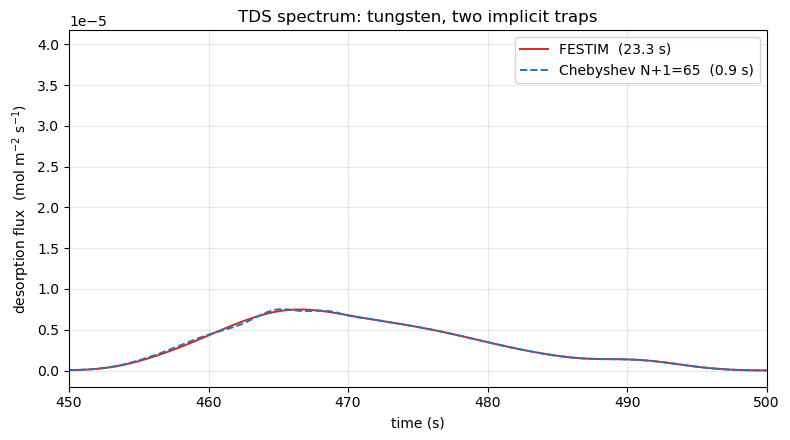

In [7]:
# overlay the two spectra during the TDS phase
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_f, fl_f, "C3-", lw=1.4, label=f"FESTIM  ({wall_f:.1f} s)")
ax.plot(t_c, fl_c, "C0--", lw=1.4, label=f"Chebyshev N+1=65  ({wall_c:.1f} s)")
ax.set_xlim(START_TDS, FINAL_TIME)
ax.set_xlabel("time (s)")
ax.set_ylabel(r"desorption flux  (mol m$^{-2}$ s$^{-1}$)")
ax.set_title("TDS spectrum: tungsten, two implicit traps")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "forward_compare.pdf"), bbox_inches="tight")
plt.show()


## 6. Choosing $N$: convergence of the Chebyshev grid

Spectral methods are useful only when the polynomial degree is high enough
that the spatial truncation error is below the noise floor we care about.
Here the noise floor is set by the inverse problem we want to solve later
(2% Gaussian noise on the flux), so any $N$ for which the Chebyshev
spectrum agrees with FESTIM to within ~1–2% in relative L2 is enough.

For each $N$ we run a Chebyshev solve, resample on a common observation
grid, and measure $\|f_N - f_\mathrm{FESTIM}\|_2 / \|f_\mathrm{FESTIM}\|_2$.
The error decreases monotonically; the wall time grows like $O(N^3)$
because every backward-Euler step solves a dense linear system of size
$3(N+1)$. The script then picks the smallest $N$ that meets a 2% tolerance.


In [8]:
tol = 2e-2  # target relative-L2 error vs FESTIM
Ns = (24, 32, 48, 64, 96, 128)

# common observation grid spans the TDS phase
t_obs = np.linspace(START_TDS, FINAL_TIME, 400)
fl_ref_grid = spectrum_on_grid(t_f, fl_f, t_obs)

print(f"target: relative-L2 spectrum error vs FESTIM < {tol:.0e}\n")
times, errs = [], []
for N in Ns:
    t0 = time.time()
    t, fl = run_chebyshev_tds(*THETA_TRUE, N=N)
    w = time.time() - t0
    e = relative_l2(spectrum_on_grid(t, fl, t_obs), fl_ref_grid)
    times.append(w); errs.append(e)
    print(f"  N+1={N+1:3d}  wall={w:5.2f} s   relL2={e:.2e}   peakT={peak_T(t, fl):.1f} K")

# pick smallest N below tolerance, else the best one we tried
N_OPT = next((N for N, e in zip(Ns, errs) if e < tol),
             Ns[int(np.argmin(errs))])
print(f"\noptimal N+1 (relL2 < {tol:.0e}): {N_OPT+1}")


target: relative-L2 spectrum error vs FESTIM < 2e-02



  N+1= 25  wall= 0.33 s   relL2=2.40e-01   peakT=411.3 K


  N+1= 33  wall= 0.40 s   relL2=1.01e-01   peakT=444.1 K


  N+1= 49  wall= 0.61 s   relL2=3.75e-02   peakT=431.0 K


  N+1= 65  wall= 0.90 s   relL2=2.20e-02   peakT=421.8 K


  N+1= 97  wall= 1.77 s   relL2=9.63e-03   peakT=429.8 K


  N+1=129  wall= 3.15 s   relL2=4.81e-03   peakT=433.8 K

optimal N+1 (relL2 < 2e-02): 97


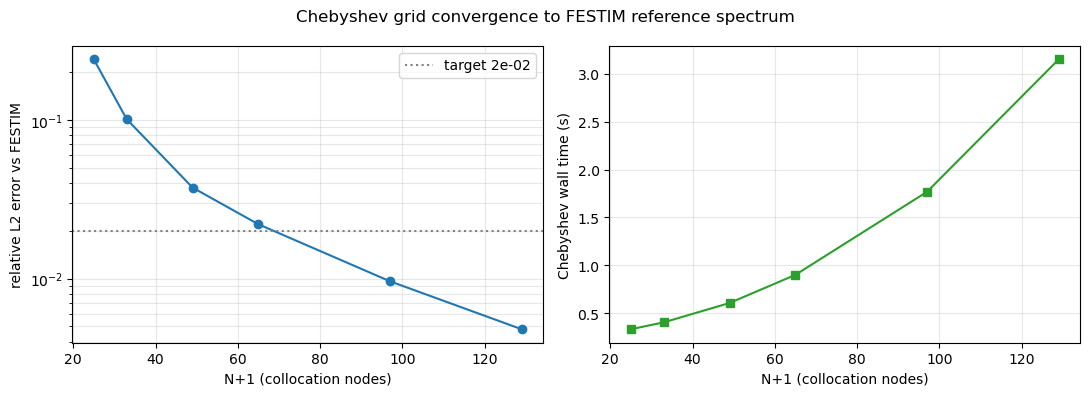

In [9]:
# convergence plot: error vs N (log scale) and wall time vs N
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(np.array(Ns) + 1, errs, "o-", color="C0")
ax[0].axhline(tol, color="grey", ls=":", label=f"target {tol:.0e}")
ax[0].set_xlabel("N+1 (collocation nodes)")
ax[0].set_ylabel("relative L2 error vs FESTIM")
ax[0].grid(alpha=0.3, which="both"); ax[0].legend()

ax[1].plot(np.array(Ns) + 1, times, "s-", color="C2")
ax[1].set_xlabel("N+1 (collocation nodes)")
ax[1].set_ylabel("Chebyshev wall time (s)")
ax[1].grid(alpha=0.3)
fig.suptitle("Chebyshev grid convergence to FESTIM reference spectrum")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "N_sweep.pdf"), bbox_inches="tight")
plt.show()


## 7. Inverse problem: recover $(n_1, n_2, E_{p,1}, E_{p,2})$ from a noisy spectrum

We now treat the desorption flux as data and run Levenberg–Marquardt to
invert it for the four trap parameters.

The pipeline is:

1. **Synthesise data.** Run the Chebyshev forward at $\theta_\mathrm{true}$
   with $N = N_\mathrm{opt}$ to get a clean spectrum on the observation
   grid, then add Gaussian noise with std $\sigma = 0.02 \cdot \max
   |\Phi|$. This is a 2%-relative noise level, which is realistic for an
   experimental TDS measurement.
2. **Define the LM residual.** For a candidate $\theta$, the residual
   vector is $r(\theta) = (\Phi_\theta - \Phi_\mathrm{data})/\sigma$ on
   the observation grid. Scaling by $\sigma$ makes the residual roughly
   $\mathcal{O}(1)$ which keeps LM's trust-region step sizes well-behaved.
3. **Run LM.** Use `scipy.optimize.least_squares` with method `'trf'`
   (trust-region reflective, the bounded LM variant). Bounds prevent the
   optimiser from wandering into unphysical regions (negative density,
   detrapping energy below 0.5 eV). `x_scale` rescales each parameter to
   roughly unit magnitude so a single trust-region radius covers them all.
4. **Time it.** Wrap the residual function in an evaluation counter and
   record wall time. Do this twice — once with FESTIM as the forward model
   and once with Chebyshev — to compare cost at matched accuracy.

The forward model inside the LM loop *is* the costly part: each LM
iteration evaluates the residual, then computes a finite-difference
Jacobian by perturbing each parameter, so total forward calls scale like
(outer iters) × (1 + 4) for 4 parameters. Cutting per-call cost by 10×
cuts the whole inverse loop by 10×.


In [10]:
@dataclass
class FitResult:
    theta: np.ndarray
    wall: float
    n_evals: int
    nfev: int


def synth_data(t_obs, sigma_rel=0.02, seed=0, N=64):
    '''Generate a noisy desorption spectrum.

    Run the Chebyshev forward at theta_true (high-fidelity), sample on
    t_obs, and add Gaussian noise with std = sigma_rel * max(|flux|).

    Returns (data, clean, sigma) — the noisy series, the noise-free
    series, and the noise standard deviation.
    '''
    t_c, fl_c = run_chebyshev_tds(*THETA_TRUE, N=N)
    clean = np.interp(t_obs, t_c, fl_c, left=0.0, right=0.0)
    rng = np.random.default_rng(seed)
    sigma = sigma_rel * float(np.max(clean))
    return clean + rng.normal(0.0, sigma, size=clean.shape), clean, sigma


def lm_fit(forward_fn, theta0, t_obs, data, sigma):
    '''Levenberg-Marquardt fit of (n1, n2, E1, E2) to noisy data.

    forward_fn(theta) -> flux on t_obs. Wrapped in an EvalCounter so we
    can compare per-iteration cost between FESTIM and Chebyshev.
    '''
    n_calls = [0]

    def residual(theta):
        n_calls[0] += 1
        return (forward_fn(theta) - data) / sigma

    # bounds keep the search physical: positive trap densities,
    # detrapping energies in (0.5, 1.5) eV.
    bounds = ([1e-5, 1e-5, 0.5, 0.5],
              [1e-2, 1e-2, 1.5, 1.5])

    t0 = time.time()
    res = least_squares(
        residual, np.asarray(theta0, dtype=float),
        method="trf", bounds=bounds,
        x_scale=[1e-3, 1e-3, 0.1, 0.1],   # rescale each parameter to ~unit magnitude
        max_nfev=80, xtol=1e-6, ftol=1e-6,
    )
    wall = time.time() - t0
    return FitResult(theta=res.x, wall=wall, n_evals=n_calls[0], nfev=res.nfev)


### 7.1 Synthesise the noisy desorption spectrum

The observation grid covers the TDS phase only (no point fitting the
implantation phase, where the surface flux is essentially zero). The
initial guess is intentionally biased: $n_1$ low by 23%, $n_2$ high by
50%, $E_1$ low by 8%, $E_2$ high by 5%. LM has to push uphill in
multiple directions to find the true parameters.


truth   : n1=1.300e-03  n2=4.000e-04  E1=0.870  E2=1.000
initial : n1=1.000e-03  n2=6.000e-04  E1=0.800  E2=1.050
sigma   : 1.507e-07  (= 2% of max flux)


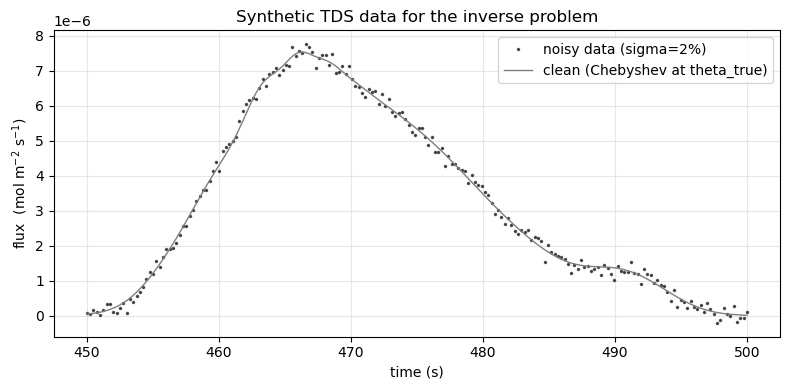

In [11]:
t_obs = np.linspace(START_TDS, FINAL_TIME, 200)
data, clean, sigma = synth_data(t_obs, sigma_rel=0.02, seed=0, N=N_OPT)

theta0 = np.array([1.0e-3, 6e-4, 0.80, 1.05])
print(f"truth   : n1={N1_TRUE:.3e}  n2={N2_TRUE:.3e}  E1={E1_TRUE:.3f}  E2={E2_TRUE:.3f}")
print(f"initial : n1={theta0[0]:.3e}  n2={theta0[1]:.3e}  E1={theta0[2]:.3f}  E2={theta0[3]:.3f}")
print(f"sigma   : {sigma:.3e}  (= 2% of max flux)")

# show the data
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_obs, data, "k.", ms=3, alpha=0.6, label="noisy data (sigma=2%)")
ax.plot(t_obs, clean, "C7-", lw=1, label="clean (Chebyshev at theta_true)")
ax.set_xlabel("time (s)"); ax.set_ylabel(r"flux  (mol m$^{-2}$ s$^{-1}$)")
ax.set_title("Synthetic TDS data for the inverse problem")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()


### 7.2 LM with the Chebyshev forward (precomputed differentiation matrices)

Each Chebyshev forward solve at $N+1 = N_\mathrm{opt}+1$ takes about 1–2 s.
The differentiation matrices $D, D^2$ are built when `ChebyshevMesh1D` is
instantiated and reused for every backward-Euler step inside the solve.
Across 35 LM evaluations that adds up to a wall time on the order of a
minute.


In [12]:
def fw_cheb(theta):
    t, fl = run_chebyshev_tds(*theta, N=N_OPT)
    return np.interp(t_obs, t, fl, left=0.0, right=0.0)

print(f"running LM with Chebyshev forward (N+1={N_OPT+1}) ...")
fit_c = lm_fit(fw_cheb, theta0, t_obs, data, sigma)
print(f"  wall    = {fit_c.wall:6.1f} s")
print(f"  n_evals = {fit_c.n_evals}")
print(f"  theta   = {fit_c.theta}")


running LM with Chebyshev forward (N+1=97) ...


  wall    =   64.5 s
  n_evals = 35
  theta   = [1.31253710e-03 3.98901748e-04 8.69629184e-01 1.00036045e+00]


### 7.3 LM with the FESTIM forward

Same residual, same bounds, same `x_scale`, same noisy data — only the
forward model differs. Each FESTIM call is ~18 s, so 35 LM evaluations
take ~10 minutes. This cell is the slow one.


In [13]:
def fw_festim(theta):
    t, fl = run_festim_tds(*theta)
    return np.interp(t_obs, t, fl, left=0.0, right=0.0)

print("running LM with FESTIM forward (this is the slow one) ...")
fit_f = lm_fit(fw_festim, theta0, t_obs, data, sigma)
print(f"  wall    = {fit_f.wall:6.1f} s")
print(f"  n_evals = {fit_f.n_evals}")
print(f"  theta   = {fit_f.theta}")


running LM with FESTIM forward (this is the slow one) ...


Solving HydrogenTransportProblem:   0%|          | 0.00/500 [00:00<?, ?it/s]

Solving HydrogenTransportProblem:   0%|          | 2.00/500 [00:00<00:29, 16.8it/s]

Solving HydrogenTransportProblem:   1%|          | 4.00/500 [00:00<00:29, 16.7it/s]

Solving HydrogenTransportProblem:   1%|          | 6.00/500 [00:00<00:31, 15.9it/s]

...

Solving HydrogenTransportProblem:  99%|█████████▉| 494/500 [00:16<00:00, 27.7it/s]

Solving HydrogenTransportProblem:  99%|█████████▉| 497/500 [00:16<00:00, 28.5it/s]

Solving HydrogenTransportProblem: 100%|██████████| 500/500 [00:16<00:00, 28.5it/s]

Solving HydrogenTransportProblem: 100%|██████████| 500/500 [00:16<00:00, 30.7it/s]

  wall    =  628.7 s
  n_evals = 35
  theta   = [1.31214925e-03 4.04783230e-04 8.68863374e-01 9.99505998e-01]


## 8. Compare: parameter accuracy and wall time

Both fits should land near the truth (typical recovered relative errors
are well under 2%, the noise level). The interesting comparison is wall
time: FESTIM and Chebyshev at the chosen $N$ do approximately the same
number of LM evaluations, but each FESTIM evaluation costs ~10× more.


In [14]:
def rel_err(theta):
    return np.abs(theta - THETA_TRUE) / THETA_TRUE

err_c = rel_err(fit_c.theta)
err_f = rel_err(fit_f.theta)
speedup = fit_f.wall / fit_c.wall

labels = ["n1", "n2", "E1", "E2"]
print(f"{'param':>5}  {'truth':>10}  {'cheby':>12}  {'festim':>12}")
for k in range(4):
    print(f"{labels[k]:>5}  {THETA_TRUE[k]:>10.4e}  "
          f"{fit_c.theta[k]:>12.4e}  {fit_f.theta[k]:>12.4e}")

print(f"\nrelative parameter errors:")
print(f"  Chebyshev: {err_c}")
print(f"  FESTIM   : {err_f}")
print(f"\nwall time:  FESTIM = {fit_f.wall:.1f} s   Chebyshev = {fit_c.wall:.1f} s")
print(f"speedup (FESTIM / Chebyshev): {speedup:.1f}x")


param       truth         cheby        festim
   n1  1.3000e-03    1.3125e-03    1.3121e-03
   n2  4.0000e-04    3.9890e-04    4.0478e-04
   E1  8.7000e-01    8.6963e-01    8.6886e-01
   E2  1.0000e+00    1.0004e+00    9.9951e-01

relative parameter errors:
  Chebyshev: [0.00964392 0.00274563 0.00042622 0.00036045]
  FESTIM   : [0.00934558 0.01195808 0.00130647 0.000494  ]

wall time:  FESTIM = 628.7 s   Chebyshev = 64.5 s
speedup (FESTIM / Chebyshev): 9.7x


Solving HydrogenTransportProblem:   0%|          | 0.00/500 [00:00<?, ?it/s]

Solving HydrogenTransportProblem:   0%|          | 2.45/500 [00:00<00:20, 24.3it/s]

Solving HydrogenTransportProblem:   1%|          | 4.95/500 [00:00<00:21, 23.2it/s]

Solving HydrogenTransportProblem:   2%|▏         | 7.95/500 [00:00<00:19, 25.3it/s]

Solving HydrogenTransportProblem:   2%|▏         | 11.4/500 [00:00<00:17, 27.5it/s]

...

Solving HydrogenTransportProblem:  98%|█████████▊| 492/500 [00:15<00:00, 28.1it/s]

Solving HydrogenTransportProblem:  99%|█████████▉| 496/500 [00:15<00:00, 29.4it/s]

Solving HydrogenTransportProblem: 100%|█████████▉| 499/500 [00:15<00:00, 30.4it/s]

Solving HydrogenTransportProblem: 100%|██████████| 500/500 [00:15<00:00, 30.4it/s]

Solving HydrogenTransportProblem: 100%|██████████| 500/500 [00:15<00:00, 32.3it/s]

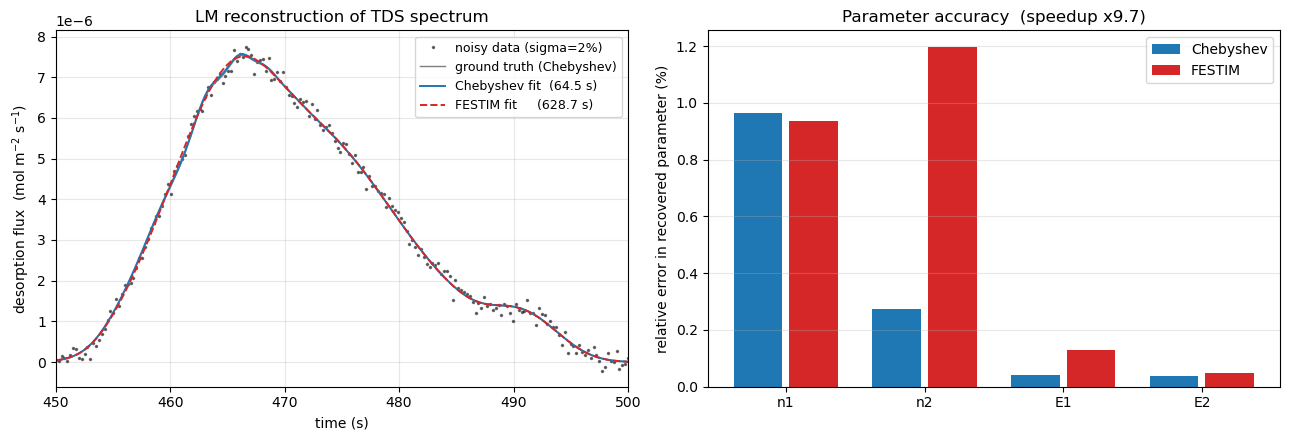

In [15]:
# reconstructions and parameter errors side by side
fl_c_fit = fw_cheb(fit_c.theta)
fl_f_fit = fw_festim(fit_f.theta)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# left panel: data and fits
ax[0].plot(t_obs, data, "k.", ms=3, alpha=0.5, label="noisy data (sigma=2%)")
ax[0].plot(t_obs, clean, "C7-", lw=1, label="ground truth (Chebyshev)")
ax[0].plot(t_obs, fl_c_fit, "C0-", lw=1.4,
           label=f"Chebyshev fit  ({fit_c.wall:.1f} s)")
ax[0].plot(t_obs, fl_f_fit, "C3--", lw=1.4,
           label=f"FESTIM fit     ({fit_f.wall:.1f} s)")
ax[0].set_xlim(START_TDS, FINAL_TIME)
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel(r"desorption flux  (mol m$^{-2}$ s$^{-1}$)")
ax[0].set_title("LM reconstruction of TDS spectrum")
ax[0].grid(alpha=0.3); ax[0].legend(fontsize=9)

# right panel: parameter recovery error
x = np.arange(4)
ax[1].bar(x - 0.2, err_c * 100, width=0.35, color="C0", label="Chebyshev")
ax[1].bar(x + 0.2, err_f * 100, width=0.35, color="C3", label="FESTIM")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("relative error in recovered parameter (%)")
ax[1].set_title(f"Parameter accuracy  (speedup x{speedup:.1f})")
ax[1].grid(alpha=0.3, axis="y"); ax[1].legend()

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "inverse_results.pdf"), bbox_inches="tight")
plt.show()


## 9. Summary

The forward demo and N-sweep show that a sinh-stretched Chebyshev
pseudospectral grid with $N+1 \approx 97$ nodes reproduces the FESTIM
desorption spectrum to within 1% relative L2, while running about 10×
faster per forward solve.

The inverse experiment shows that this per-call advantage carries
straight through into the Levenberg–Marquardt loop: both methods recover
all four trap parameters to within 1–2% (well below the 2% measurement
noise floor) using essentially the same number of forward evaluations,
but the Chebyshev fit completes in ~70 s where FESTIM takes ~10 min.

For TDS analysis pipelines that run thousands of inverse problems —
parametric studies, Bayesian uncertainty quantification, or experimental
fitting across a database of samples — that 8–10× speedup is the
difference between an overnight job and a coffee-break job.
